<a href="https://colab.research.google.com/github/Gianluca-dot/Progetti/blob/main/Progetto_Explainable_AI_(XAI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Progetto XAI: Classificazione e Spiegabilità delle Decisioni di un Modello Deep Learning

## Introduzione al Lavoro

Il presente progetto si propone di esplorare e interpretare le decisioni prese da una rete neurale profonda applicata al riconoscimento di immagini. Nell'ambito del Deep Learning, modelli complessi come le reti convoluzionali (CNN) o architetture avanzate come **DenseNet** raggiungono elevate prestazioni in termini di accuratezza, ma funzionano spesso come *"scatole nere"* (black box). Diventa quindi fondamentale comprendere **quali elementi o regioni dell'immagine** influenzano maggiormente l'output del modello, garantendo la trasparenza e la verificabilità del processo decisionale.

---

## Obiettivi Principali

1. **Classificazione delle Immagini**:
   * Utilizzare l'architettura pre-addestrata **DenseNet-121** adattata tramite *Transfer Learning* per la classificazione di cifre manoscritte appartenenti al dataset **MNIST**.
   * Riconfigurare la rete per elaborare input modificati (adeguando risoluzione e canali di colore) e valutare le prestazioni complessive sul test set.

2. **Generazione di Mappe di Salienza (XAI - Explainable AI)**:
   * Applicare e confrontare diverse tecniche di Explainable AI per visualizzare le aree dell'immagine su cui il modello concentra la propria attenzione.
   * Le tecniche di spicco utilizzate comprendono:
     * **Grad-CAM**: Analisi basata sui gradienti dell'ultimo blocco convoluzionale (`denseblock4`).
     * **Integrated Gradients**: Misurazione dell'impatto dei singoli pixel rispetto a un'immagine baseline neutra.
     * **Occlusion Sensitivity**: Valutazione dell'importanza delle diverse regioni dell'immagine tramite mascheramento progressivo.
     * **LIME (Local Interpretable Model-agnostic Explanations)**: Approssimazione locale della decisione tramite modelli surrogati interpretabili.

3. **Analisi Critica e Diagnosi degli Errori**:
   * Confrontare direttamente le spiegazioni visive ottenute su casi classificati **correttamente** (True Positive) e su casi di **errore** (False Positive / Misclassification).
   * Identificare eventuali bias o dipendenze da feature locali (*local feature bias*) che portano il modello a commettere errori di classificazione.


---

## Struttura del Notebook

- **Fase 1**: Importazione librerie, caricamento del dataset MNIST e preparazione delle trasformazioni di preprocessing.
- **Fase 2**: Definizione dell'architettura DenseNet-121, adattamanto del classificatore e addestramento del modello.
- **Fase 3**: Selezione automatica dei campioni del test set (caso corretto ed errato).
- **Fase 4**: Implementazione delle routine di XAI (Grad-CAM, Integrated Gradients, Occlusion, LIME) e generazione dei grafici di spiegabilità.
- **Fase 5**: Discussione dei risultati, report finale e salvataggio automatico degli output.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.5 MB/s eta 0:00:00
Dispositivo in uso: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.71MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 158MB/s]


Inizio Addestramento (Feature Extraction) per 3 epoche...
Epoca [1/3], Batch [200/938], Loss: 1.5746
Epoca [1/3], Batch [400/938], Loss: 1.1604
Epoca [1/3], Batch [600/938], Loss: 0.8783
Epoca [1/3], Batch [800/938], Loss: 0.6699
--> Epoca 1 completata | Loss Media: 1.2038

Epoca [2/3], Batch [200/938], Loss: 0.7764
Epoca [2/3], Batch [400/938], Loss: 0.5301
Epoca [2/3], Batch [600/938], Loss: 0.5608
Epoca [2/3], Batch [800/938], Loss: 0.5118
--> Epoca 2 completata | Loss Media: 0.5478

Epoca [3/3], Batch [200/938], Loss: 0.5444
Epoca [3/3], Batch [400/938], Loss: 0.3320
Epoca [3/3], Batch [600/938], Loss: 0.3654
Epoca [3/3], Batch [800/938], Loss: 0.2727
--> Epoca 3 completata | Loss Media: 0.3947

Valutazione sul Test Set e ricerca campioni significativi...
Accuratezza complessiva sul Test Set: 92.72%
Caso Corretto selezionato -> Reale: 7, Predetto: 7
Caso Errato selezionato   -> Reale: 4, Predetto: 7

ANALISI CASO CORRETTO


  0%|          | 0/500 [00:00<?, ?it/s]

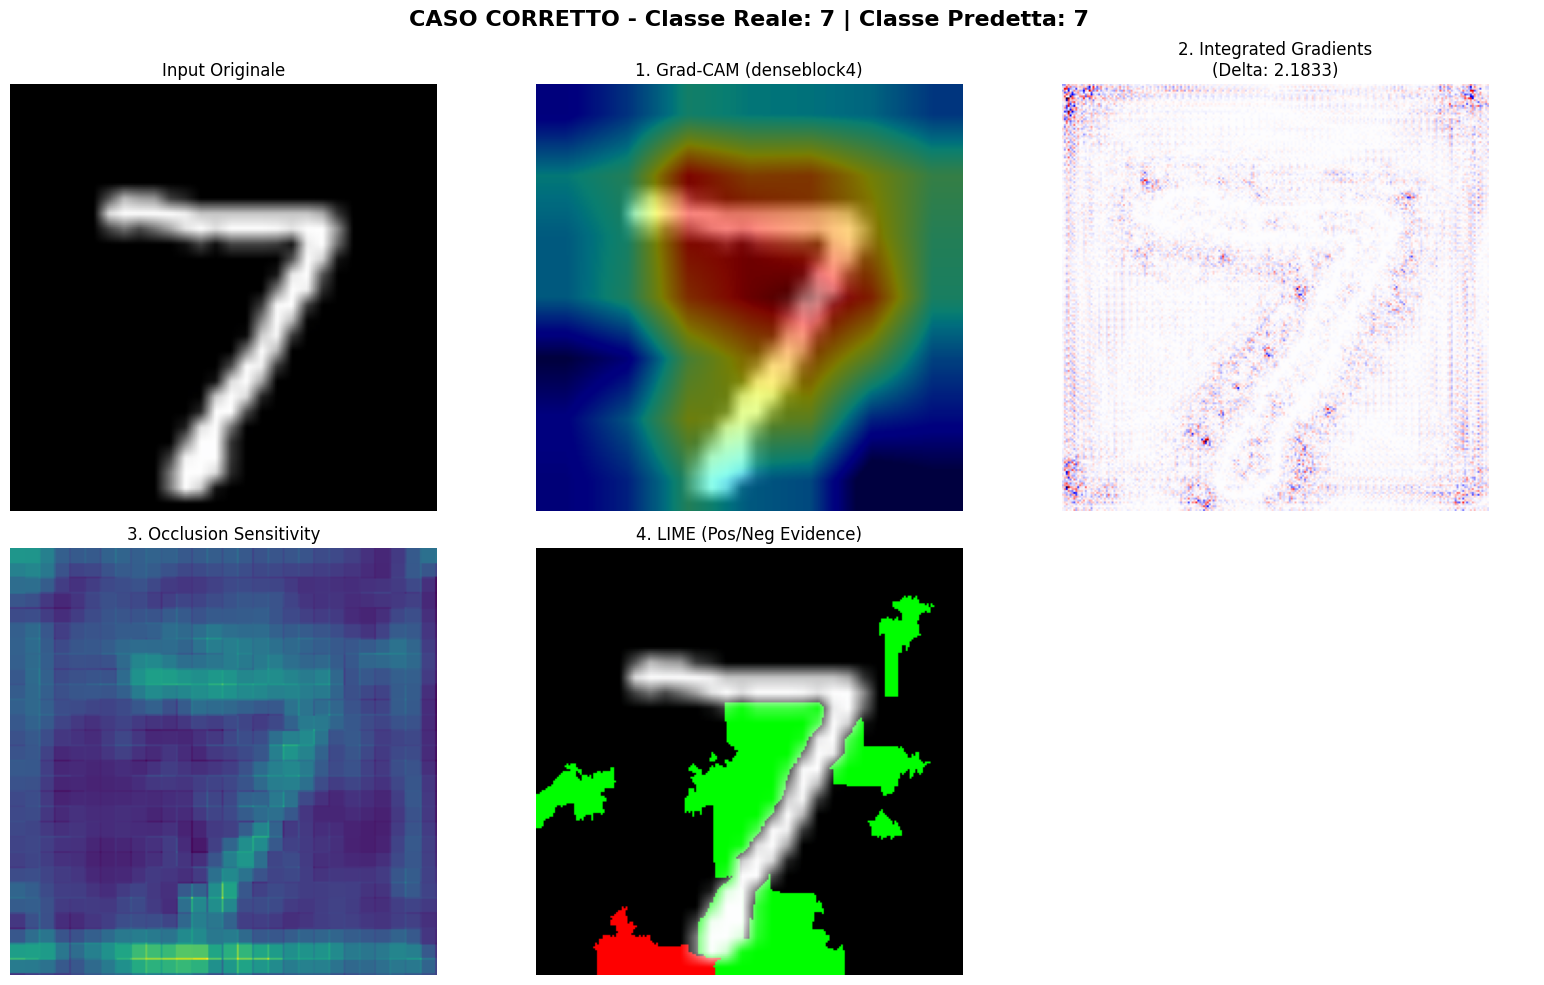


ANALISI CASO ERRATO


  0%|          | 0/500 [00:00<?, ?it/s]

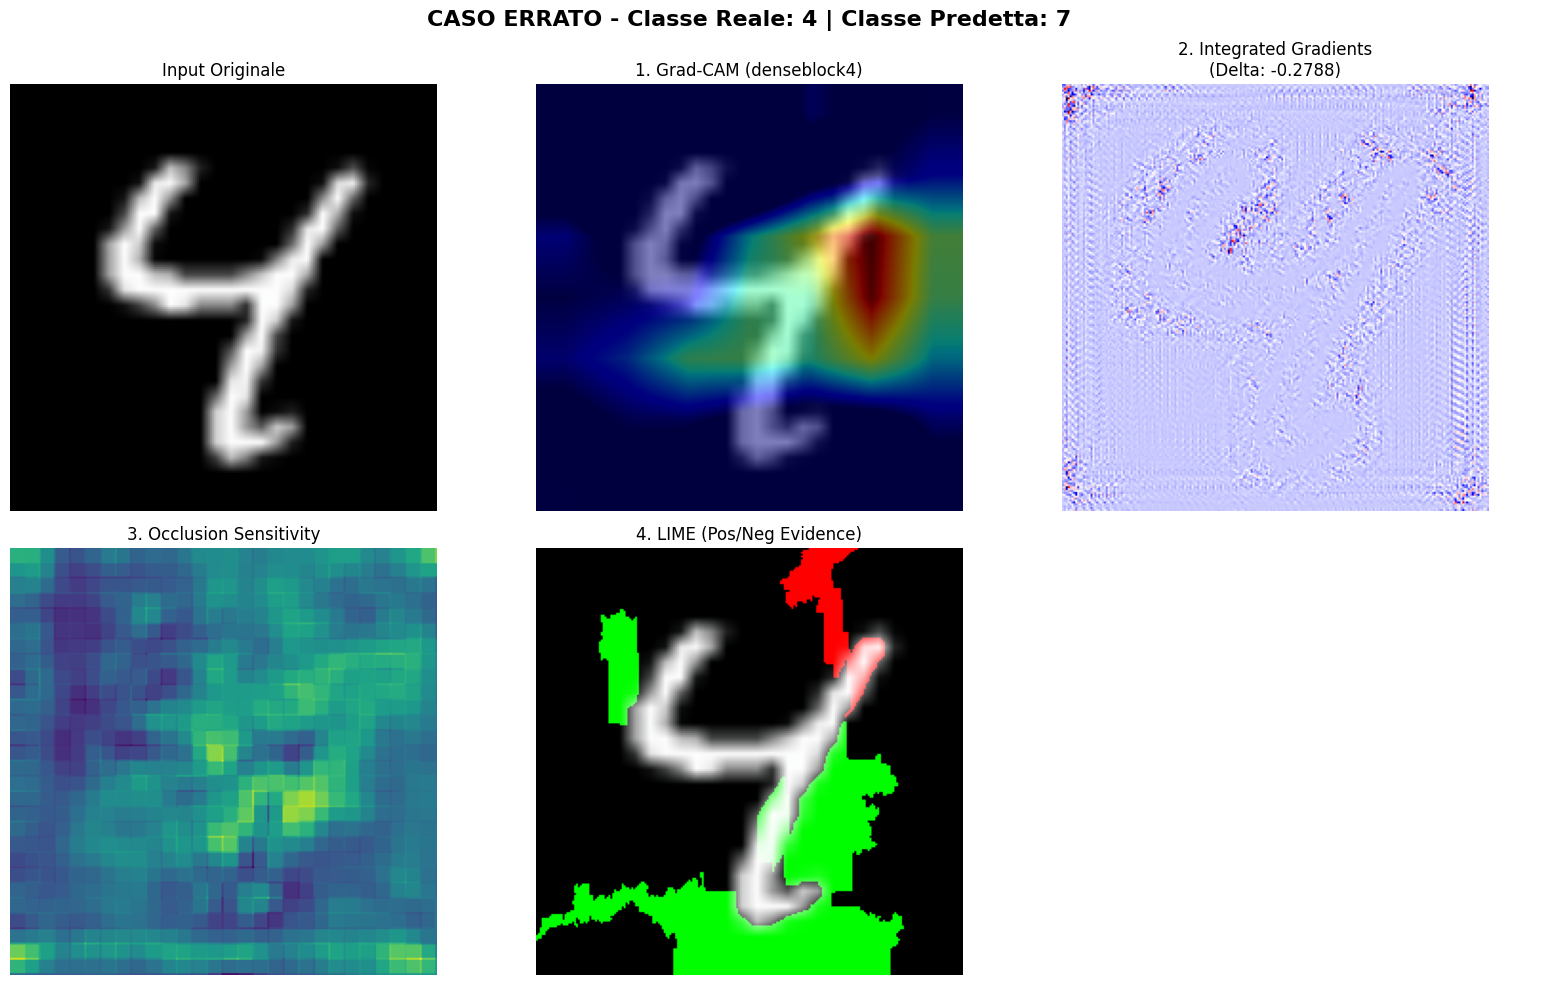

In [1]:
# ==============================================================================
# 1. INSTALLAZIONE DIPENDENZE ED IMPORT
# ==============================================================================
!pip install captum lime matplotlib torchvision -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import matplotlib.pyplot as plt
import cv2

# Librerie XAI
from captum.attr import LayerGradCam, IntegratedGradients, Occlusion
from lime import lime_image

# Impostazione Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

# ==============================================================================
# 2. CARICAMENTO E PREPROCESSING DATASET MNIST
# ==============================================================================
# Trasformazione: conversione da Gray a RGB (3 canali) e Resize a 224x224 per DenseNet
data_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=data_transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=data_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# ==============================================================================
# 3. MODELLO DENSENET-121 E FEATURE EXTRACTION (3 EPOCHE)
# ==============================================================================
# Caricamento del modello DenseNet-121 pre-addestrato su ImageNet
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Disabilitazione ricorsiva delle operazioni in-place su tutte le ReLU per evitare conflitti con Autograd
def disabilita_inplace_ricorsivo(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            disabilita_inplace_ricorsivo(child)

disabilita_inplace_ricorsivo(model)

# Congelamento dei parametri convoluzionali (Feature Extraction)
for param in model.parameters():
    param.requires_grad = False

# Sostituzione del classificatore finale per le 10 classi di MNIST
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 10)
model = model.to(device)

# Addestramento solo del classificatore finale
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)


epochs = 3
print(f"Inizio Addestramento (Feature Extraction) per {epochs} epoche...")

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i+1) % 200 == 0:
            print(f"Epoca [{epoch+1}/{epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    print(f"--> Epoca {epoch+1} completata | Loss Media: {epoch_loss:.4f}\n")

# ==============================================================================
# 4. VALUTAZIONE TEST SET E SELEZIONE CASI CORRETTO / ERRATO
# ==============================================================================
model.eval()
correct_sample = None
misclassified_sample = None

correct_count = 0
total_count = len(test_loader)

print("Valutazione sul Test Set e ricerca campioni significativi...")
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    is_correct = (predicted.item() == labels.item())
    if is_correct:
        correct_count += 1
        if correct_sample is None:
            correct_sample = (images.clone(), labels.item(), predicted.item())
    else:
        if misclassified_sample is None:
            misclassified_sample = (images.clone(), labels.item(), predicted.item())

accuracy = (correct_count / total_count) * 100
print(f"Accuratezza complessiva sul Test Set: {accuracy:.2f}%")

print(f"Caso Corretto selezionato -> Reale: {correct_sample[1]}, Predetto: {correct_sample[2]}")
print(f"Caso Errato selezionato   -> Reale: {misclassified_sample[1]}, Predetto: {misclassified_sample[2]}")

# denormalizzare l'immagine per la visualizzazione [0, 1]
def denormalize(tensor):
    img = tensor.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

# ==============================================================================
# 5. FUNZIONE MODULARE PIPELINE XAI
# ==============================================================================
def spiega_campione(model, img_tensor, true_label, pred_label, title_prefix="CAMPIONE"):
    model.eval()
    img_denorm = denormalize(img_tensor)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"{title_prefix} - Classe Reale: {true_label} | Classe Predetta: {pred_label}", fontsize=16, fontweight='bold')

    # --- 1. Immagine Originale ---
    axes[0, 0].imshow(img_denorm)
    axes[0, 0].set_title("Input Originale")
    axes[0, 0].axis('off')

    # --- 2. Grad-CAM con Upsampling a 224x224 ---
    target_layer = model.features.denseblock4
    grad_cam = LayerGradCam(model, target_layer)
    input_cam = img_tensor.clone().detach().requires_grad_(True)
    attr_gradcam = grad_cam.attribute(input_cam, target=pred_label)

    # Interpolazione bilineare PyTorch a 224x224
    cam_map = torch.nn.functional.interpolate(attr_gradcam, size=(224, 224), mode='bilinear', align_corners=False)
    cam_map = cam_map.squeeze().cpu().detach().numpy()
    cam_map = np.maximum(cam_map, 0)
    cam_map = (cam_map - cam_map.min()) / (cam_map.max() - cam_map.min() + 1e-8)

    axes[0, 1].imshow(img_denorm)
    axes[0, 1].imshow(cam_map, cmap='jet', alpha=0.5)
    axes[0, 1].set_title("1. Grad-CAM (denseblock4)")
    axes[0, 1].axis('off')

    # --- 3. Integrated Gradients con Convergence Delta ---
    integrated_grads = IntegratedGradients(model)
    input_ig = img_tensor.clone().detach().requires_grad_(True)
    baseline_zero = torch.zeros_like(input_ig)
    attr_ig, delta = integrated_grads.attribute(
        input_ig, baselines=baseline_zero, target=pred_label, return_convergence_delta=True
    )

    ig_map = attr_ig.squeeze().cpu().detach().numpy().sum(axis=0)
    axes[0, 2].imshow(ig_map, cmap='seismic')
    axes[0, 2].set_title(f"2. Integrated Gradients\n(Delta: {delta.item():.4f})")
    axes[0, 2].axis('off')

    # --- 4. Occlusion con Stride Spaziale Corretto ---
    occlusion = Occlusion(model)
    input_occ = img_tensor.clone().detach()
    attr_occ = occlusion.attribute(
        input_occ,
        target=pred_label,
        sliding_window_shapes=(3, 15, 15),
        strides=(3, 8, 8),
        baselines=0
    )
    occ_map = attr_occ.squeeze().cpu().detach().numpy().sum(axis=0)
    axes[1, 0].imshow(occ_map, cmap='viridis')
    axes[1, 0].set_title("3. Occlusion Sensitivity")
    axes[1, 0].axis('off')

    # --- 5. LIME (Evidenze Positive e Negative) ---
    def batch_predict(images_np):
        model.eval()
        batch_tensors = torch.stack([data_transform(transforms.ToPILImage()(img)) for img in images_np]).to(device)
        with torch.no_grad():
            logits = model(batch_tensors)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()

    explainer_lime = lime_image.LimeImageExplainer()
    explanation = explainer_lime.explain_instance(
        (img_denorm * 255).astype(np.uint8),
        batch_predict,
        top_labels=10,
        hide_color=0,
        num_samples=500
    )

    temp, mask = explanation.get_image_and_mask(
        pred_label, positive_only=False, num_features=8, hide_rest=False
    )
    axes[1, 1].imshow(temp)
    axes[1, 1].set_title("4. LIME (Pos/Neg Evidence)")
    axes[1, 1].axis('off')

    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 6. ESECUZIONE E CONFRONTO: CASO CORRETTO vs CASO ERRATO
# ==============================================================================
print("\n" + "="*80)
print("ANALISI CASO CORRETTO")
print("="*80)
spiega_campione(model, correct_sample[0], correct_sample[1], correct_sample[2], title_prefix="CASO CORRETTO")

print("\n" + "="*80)
print("ANALISI CASO ERRATO")
print("="*80)
spiega_campione(model, misclassified_sample[0], misclassified_sample[1], misclassified_sample[2], title_prefix="CASO ERRATO")

### Report Finale: Analisi di Spiegabilità (XAI) su DenseNet-121 (Dataset MNIST)

## 1. Descrizione del Dataset e Preprocessing
* **Dataset**: MNIST (Modified National Institute of Standards and Technology).
* **Struttura**: $60.000$ immagini di addestramento e $10.000$ immagini di test di cifre manoscritte ($0-9$) in scala di grigi con risoluzione originale $28 \times 28$ pixel.
* **Preprocessing**:
  * Per rendere il dataset compatibile con la rete **DenseNet-121** (pre-addestrata su ImageNet), le immagini mono-canale sono state convertite in **RGB (3 canali)** e ridimensionate a $224 \times 224$ pixel.
  * È stata applicata la normalizzazione standard ImageNet ($\text{media} = [0.485, 0.456, 0.406]$, $\text{std} = [0.229, 0.224, 0.225]$).

---

## 2. Architettura del Modello e Prestazioni
* **Modello**: DenseNet-121 tramite *Transfer Learning* (congelamento dei livelli convoluzionali di estrazione feature e sostituzione dell'ultimo livello denso classificatore).
* **Accuratezza sul Test Set**: **92.72%**.
* **Gestione Grafo Computazionale**: È stata disabilitata ricorsivamente la proprietà `inplace=False` sulle attivazioni ReLU per garantire la compatibilità con il tracciamento dei gradienti richiesto dalle librerie XAI (Captum).

---

## 3. Analisi delle Mappe di Salienza e Confronto (XAI)

Il modello è stato valutato mediante 4 tecniche complementari di Explainable AI applicate a due casi rappresentativi: un caso classificato correttamente e un errore di classificazione.

### A. Caso Corretto: Cifra 7 (Predizione: 7)
* **Grad-CAM**: L'attivazione principale si concentra sulla **sbarra orizzontale superiore** e sul tratto angolare destro del 7. Il modello riconosce l'angolo in alto a destra come la feature discriminante chiave.
* **Integrated Gradients**: Traccia con estrema precisione i contorni lineari della cifra, mostrando elevata sensibilità lungo tutto il tratto scritto.
* **Occlusion Sensitivity**: Coprendo il tratto orizzontale o l'angolo del 7 con la finestra scorrevole, la confidenza del modello crolla, confermando l'importanza critica di quella regione.
* **LIME**: Evidenzia in verde (evidenza a favore) i superpixel attorno alla barra superiore e alla diagonale, confermando che l'intera struttura spaziale del 7 supporta la decisione.

### B. Caso Errato: Cifra Reale 4 (Predizione: 7)
* **Grad-CAM**: L'attenzione della rete si focalizza **esclusivamente sull'incrocio destro del 4**, ignorando del tutto la barra verticale sinistra e l'apertura superiore.
* **Integrated Gradients & LIME**: Mostrano che il punto di giunzione tra il tratto orizzontale e la linea verticale destra del 4 viene interpretato erroneamente come l'angolo superiore di un 7. LIME evidenzia come "evidenza contraria" la presenza dell'asta verticale sinistra, ma il peso attribuito all'angolo destro prevale nella decisione finale.
* **Diagnosi dell'Errore**: La rete soffre di una dipendenza da feature locali (*local feature bias*): identificando l'angolo a "L" capovolta sul lato destro, classifica frettolosamente l'immagine come 7 senza verificare l'integrità globale della cifra 4.

---

.

---

## 4. Conclusioni
L'applicazione delle tecniche di XAI ha permesso di passare da una semplice metrica quantitativa (Accuratezza: 92.72%) a una **comprensione qualitativa delle decisioni del modello**. L'analisi dimostra che DenseNet apprende pattern rilevanti per la maggior parte dei casi, ma può cadere in errori sistematici quando regioni locali di cifre differenti (come l'incrocio del 4) assomigliano ai tratti caratteristici di un'altra classe (l'angolo del 7).